# SARIMAX with Exogenous Variables

In this notebook, we will use the **Power Consumption of Tetouan City** dataset.

The goal is to predict electricity consumption using time series models.

We will compare:

1. **SARIMA**: uses only the past values of the target.
2. **SARIMAX**: uses the past values of the target plus external variables.

The target will be:

`Zone 1 Power Consumption`

The exogenous variables will be:

- Temperature
- Humidity
- Wind Speed
- general diffuse flows
- diffuse flows
- calendar variables

https://archive.ics.uci.edu/dataset/849/power%2Bconsumption%2Bof%2Btetouan%2Bcity

In [1]:
%pip install ucimlrepo statsmodels scikit-learn -q

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

## 1. Load the dataset

First, we load the dataset from UCI.

The dataset contains power consumption data from Tetouan, Morocco.

It has weather variables, light-related variables, and power consumption for three different zones.

In [3]:
dataset = fetch_ucirepo(id=849)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


## 2. Explore the dataset

Before modeling, we need to understand the dataset.

We will check:

- the number of rows and columns
- the column names
- the data types
- missing values
- the date range

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [5]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

df = df.set_index("DateTime").sort_index()

df.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [6]:
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Number of rows:", len(df))

Start date: 2017-01-01 00:00:00
End date: 2017-12-30 23:50:00
Number of rows: 52416


Every ten minutes. Data from one year.

## 3. Seasonal decomposition

Before building the models, we can decompose the time series into three main parts:

- **Trend**: the long-term movement of the series
- **Seasonality**: repeated patterns over time
- **Residuals**: what is left after removing trend and seasonality

Since the original dataset has observations every 10 minutes, we will first resample it to hourly data.

For hourly data, a daily seasonal pattern has period 24.

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

target = "Zone 1 Power Consumption"

df_hourly = df.resample("h").mean()

df_hourly.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433


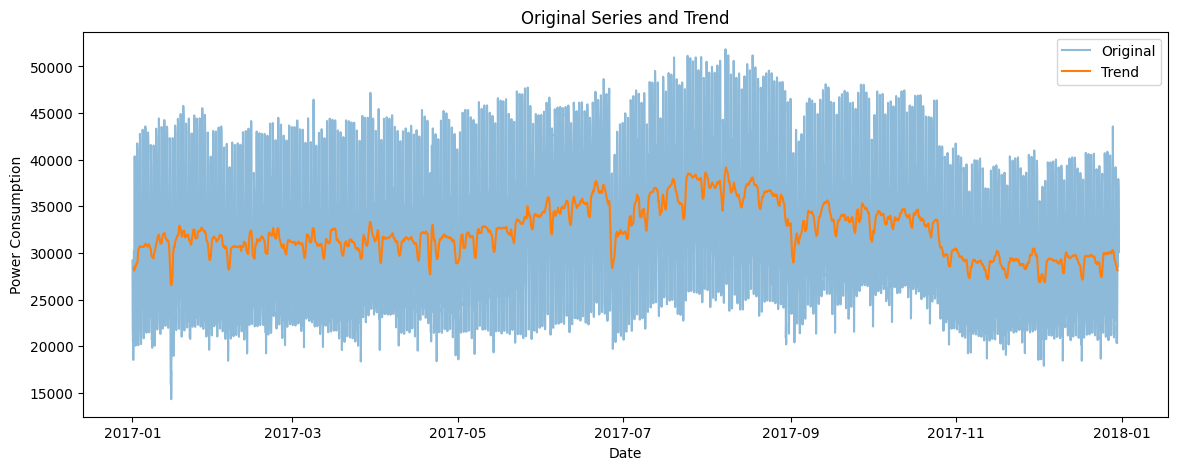

In [14]:
decomposition_day = seasonal_decompose(
    df_hourly[target],
    model="additive",
    period=24
)

plt.figure(figsize=(14, 5))

plt.plot(df_hourly.index, df_hourly[target], label="Original", alpha=0.5)
plt.plot(decomposition_day.trend.index, decomposition_day.trend, label="Trend")

plt.title("Original Series and Trend")
plt.xlabel("Date")
plt.ylabel("Power Consumption")
plt.legend()
plt.show()

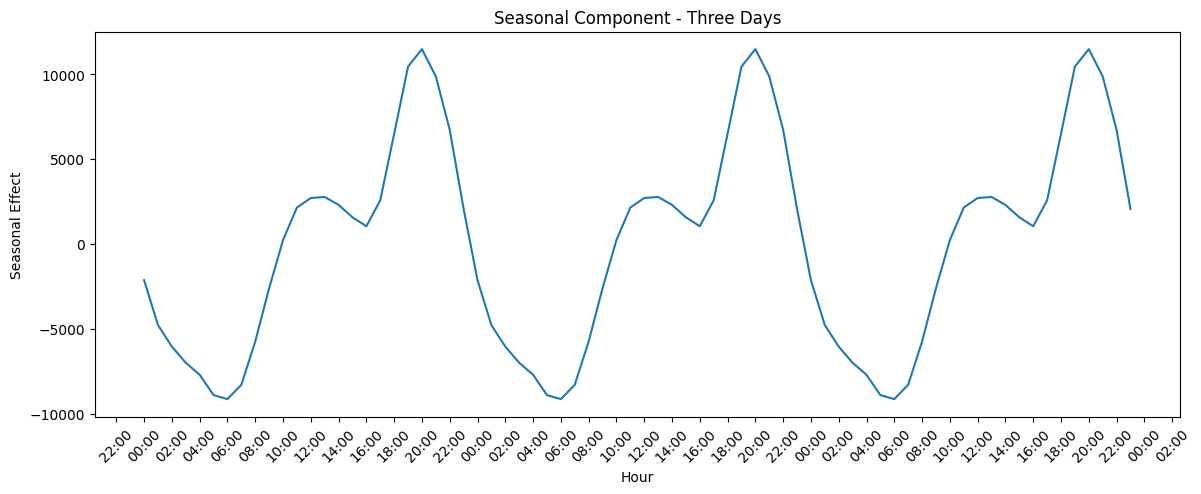

In [17]:
import matplotlib.dates as mdates

seasonal_sample = decomposition_day.seasonal.loc["2017-07-03":"2017-07-05 23:00"]

plt.figure(figsize=(14, 5))

plt.plot(seasonal_sample.index, seasonal_sample)

plt.title("Seasonal Component - Three Days")
plt.xlabel("Hour")
plt.ylabel("Seasonal Effect")

plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.xticks(rotation=45)

plt.show()

For a weekly seasonal decomposition, you can also show this:

In [21]:
df_daily = df_hourly[target].resample("D").mean()

df_daily.head()

,Zone 1 Power Consumption
DateTime,
2017-01-01,28465.232067
2017-01-02,28869.493671
2017-01-03,30562.447257
2017-01-04,30689.831224
2017-01-05,30802.911393


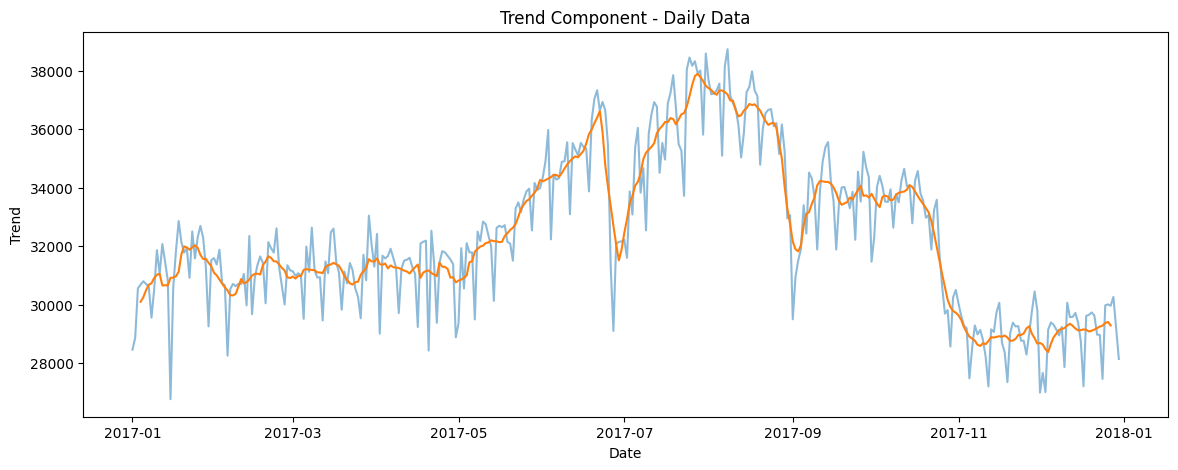

In [29]:
decomposition_daily_weekly = seasonal_decompose(
    df_daily,
    model="additive",
    period=7
)
plt.figure(figsize=(14, 5))

plt.plot(df_daily.index, df_daily, label="Original", alpha=0.5)
plt.plot(decomposition_daily_weekly.trend.index, decomposition_daily_weekly.trend)

plt.title("Trend Component - Daily Data")
plt.xlabel("Date")
plt.ylabel("Trend")

plt.show()

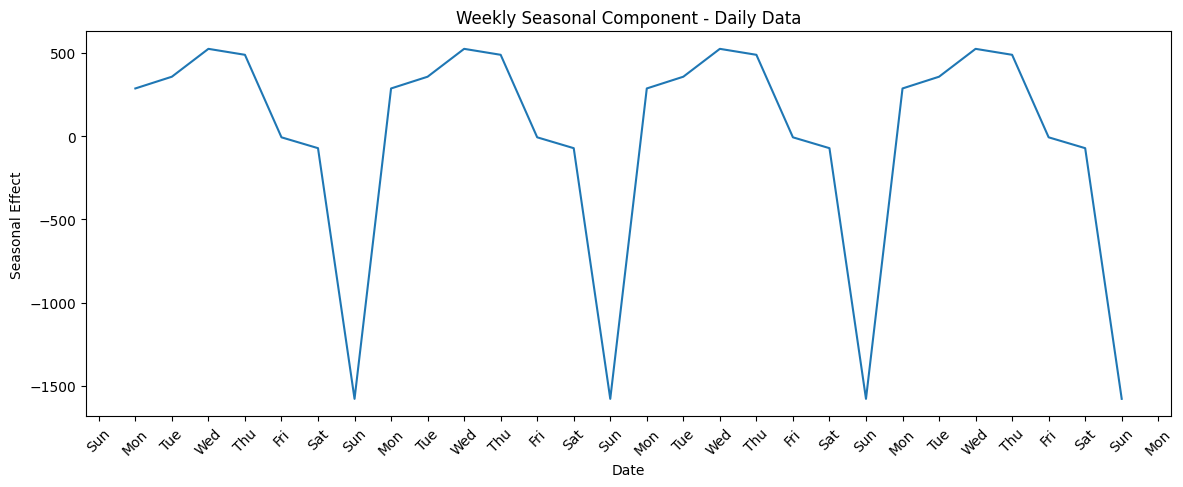

In [23]:
import matplotlib.dates as mdates

weekly_seasonal = decomposition_daily_weekly.seasonal.dropna()

weekly_sample = weekly_seasonal.loc["2017-07-03":"2017-07-30"]

plt.figure(figsize=(14, 5))

plt.plot(weekly_sample.index, weekly_sample)

plt.title("Weekly Seasonal Component - Daily Data")
plt.xlabel("Date")
plt.ylabel("Seasonal Effect")

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%a"))

plt.xticks(rotation=45)

plt.show()

## 4. Exogenous variables

Now we will prepare the exogenous variables.

The target is:

`Zone 1 Power Consumption`

The exogenous variables are external variables that may help explain power consumption.

We will use:

- Temperature
- Humidity
- Wind Speed
- general diffuse flows
- diffuse flows

We will also add calendar variables, because power consumption usually depends on the hour of the day and the day of the week.

In [30]:
target = "Zone 1 Power Consumption"

weather_exog = [
    "Temperature",
    "Humidity",
    "Wind Speed",
    "general diffuse flows",
    "diffuse flows"
]

df_hourly[[target] + weather_exog].head()

,Zone 1 Power Consumption,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows
DateTime,,,,,,
2017-01-01 00:00:00,29197.974683,6.196833,75.066667,0.081833,0.063500,0.098833
2017-01-01 01:00:00,24657.215190,5.548833,77.583333,0.082000,0.056833,0.112500
2017-01-01 02:00:00,22083.037973,5.054333,78.933333,0.082333,0.063000,0.129167
2017-01-01 03:00:00,20811.139240,5.004333,77.083333,0.082833,0.059833,0.141000
2017-01-01 04:00:00,20475.949367,5.097667,74.050000,0.082333,0.058000,0.122833


Before modeling, we can check the relationship between the target and the exogenous variables.

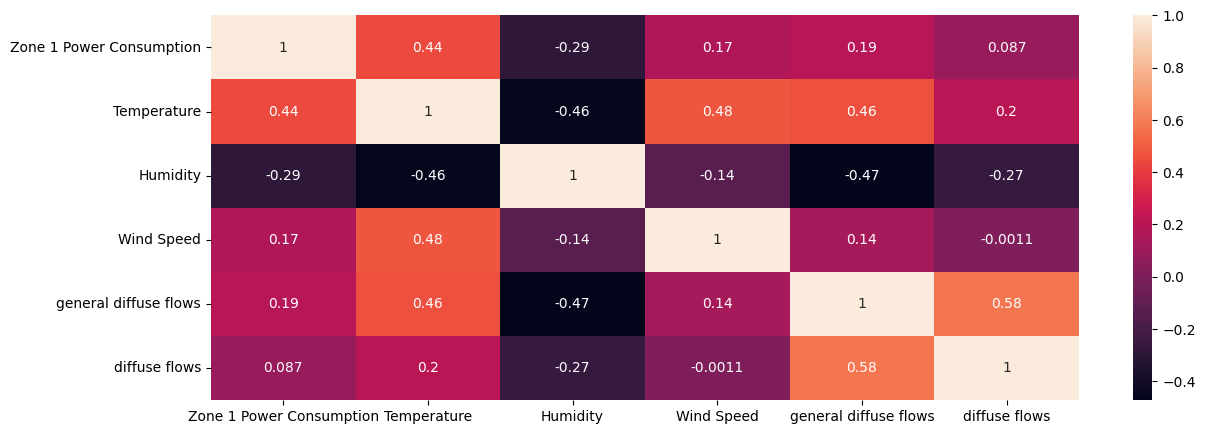

In [32]:
import seaborn as sns

plt.figure(figsize=(14, 5))

sns.heatmap(df_hourly[[target] + weather_exog].corr(), annot=True)

plt.show()

## 5. Calendar variables

Time information can also help the model.

For example, power consumption may be different:

- in the morning and at night
- during weekdays and weekends
- in different months

We will create calendar variables from the datetime index.

In [36]:
df_hourly["hour"] = df_hourly.index.hour
df_hourly["dayofweek"] = df_hourly.index.dayofweek
df_hourly["month"] = df_hourly.index.month
df_hourly["is_weekend"] = df_hourly["dayofweek"].isin([5, 6]).astype(int)

df_hourly.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,hour,dayofweek,month,is_weekend
DateTime,,,,,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193,0,6,1,1
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567,1,6,1,1
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578,2,6,1,1
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422,3,6,1,1
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433,4,6,1,1


The hour variable is cyclical.

Hour 23 and hour 0 are close to each other, but if we use only the raw number, the model may not understand this relationship.

So we will encode hour using sine and cosine.

In [37]:
df_hourly["hour_sin"] = np.sin(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["hour_cos"] = np.cos(2 * np.pi * df_hourly["hour"] / 24)

calendar_exog = [
    "hour_sin",
    "hour_cos",
    "dayofweek",
    "month",
    "is_weekend"
]

all_exog = weather_exog + calendar_exog

df_hourly[[target] + all_exog].head()

,Zone 1 Power Consumption,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,hour_sin,hour_cos,dayofweek,month,is_weekend
DateTime,,,,,,,,,,,
2017-01-01 00:00:00,29197.974683,6.196833,75.066667,0.081833,0.063500,0.098833,0.000000,1.000000,6,1,1
2017-01-01 01:00:00,24657.215190,5.548833,77.583333,0.082000,0.056833,0.112500,0.258819,0.965926,6,1,1
2017-01-01 02:00:00,22083.037973,5.054333,78.933333,0.082333,0.063000,0.129167,0.500000,0.866025,6,1,1
2017-01-01 03:00:00,20811.139240,5.004333,77.083333,0.082833,0.059833,0.141000,0.707107,0.707107,6,1,1
2017-01-01 04:00:00,20475.949367,5.097667,74.050000,0.082333,0.058000,0.122833,0.866025,0.500000,6,1,1


## 6. Select the modeling data

For the models, we will use the hourly dataset.

To keep SARIMA and SARIMAX faster, we will use only the second half of the year.

In [38]:
model_df = df_hourly.loc["2017-07-01":"2017-12-30"].copy()

model_df = model_df[[target] + all_exog].dropna()

print("Start:", model_df.index.min())
print("End:", model_df.index.max())
print("Rows:", len(model_df))

Start: 2017-07-01 00:00:00
End: 2017-12-30 23:00:00
Rows: 4392


## 7. Train-test split

Since this is a time series problem, we should not use a random split.

We will train on the past and test on the most recent observations.

Here, the test set will be the last 14 days.

In [39]:
test_size = 24 * 14

train = model_df.iloc[:-test_size]
test = model_df.iloc[-test_size:]

y_train = train[target]
y_test = test[target]

X_train = train[all_exog]
X_test = test[all_exog]

print("Train period:")
print(train.index.min(), "to", train.index.max())

print("\nTest period:")
print(test.index.min(), "to", test.index.max())

Train period:
2017-07-01 00:00:00 to 2017-12-16 23:00:00

Test period:
2017-12-17 00:00:00 to 2017-12-30 23:00:00


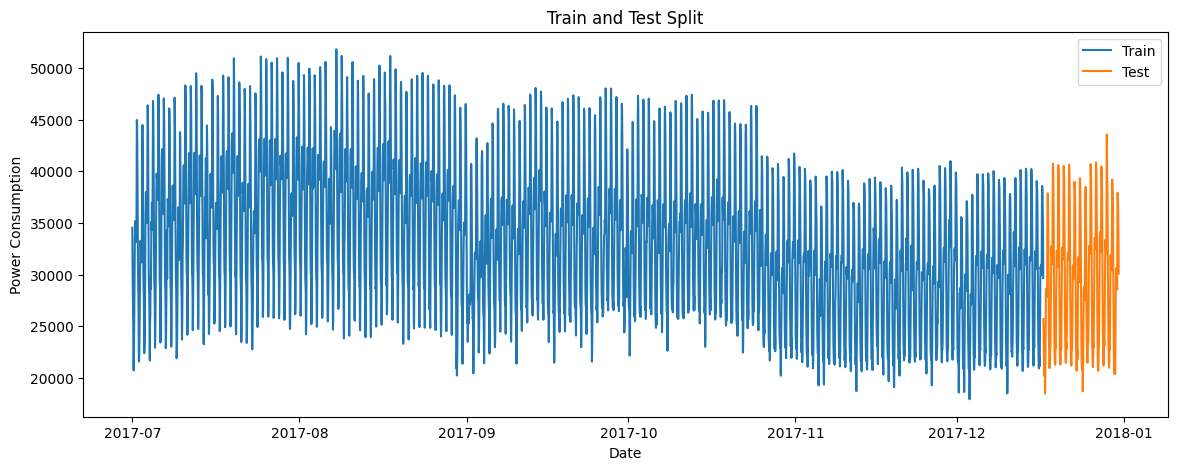

In [40]:
plt.figure(figsize=(14, 5))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test")

plt.title("Train and Test Split")
plt.xlabel("Date")
plt.ylabel("Power Consumption")
plt.legend()

plt.show()

## 8. Scale the exogenous variables

The exogenous variables have different scales.

For example:

- Temperature is usually around tens
- Diffuse flows can have larger values
- Sine and cosine variables are between -1 and 1

So we will scale the exogenous variables before using them in SARIMAX.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=all_exog,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=all_exog,
    index=X_test.index
)

X_train_scaled.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,hour_sin,hour_cos,dayofweek,month,is_weekend
DateTime,,,,,,,,,,
2017-07-01 00:00:00,-0.124020,0.257619,0.827919,-0.713259,-0.668538,2.663273e-17,1.414214,0.9941,-1.412242,1.564922
2017-07-01 01:00:00,-0.168710,0.352488,0.828274,-0.713287,-0.668409,3.660254e-01,1.366025,0.9941,-1.412242,1.564922
2017-07-01 02:00:00,-0.142916,0.262161,0.827777,-0.713252,-0.668259,7.071068e-01,1.224745,0.9941,-1.412242,1.564922
2017-07-01 03:00:00,-0.178308,0.357535,0.828061,-0.713313,-0.668224,1.000000e+00,1.000000,0.9941,-1.412242,1.564922
2017-07-01 04:00:00,-0.202003,0.354507,0.827848,-0.713283,-0.668332,1.224745e+00,0.707107,0.9941,-1.412242,1.564922


## 9. Model 1: SARIMA

The SARIMA model uses only the past values of the target variable.

It does not use exogenous variables.

Because our data is hourly, we use a seasonal period of 24 to represent daily seasonality.

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False, maxiter=50)

sarima_pred = sarima_result.forecast(steps=len(y_test))

sarima_pred.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,predicted_mean
2017-12-17 00:00:00,26017.893065
2017-12-17 01:00:00,23592.315573
2017-12-17 02:00:00,22114.795219
2017-12-17 03:00:00,21220.235302
2017-12-17 04:00:00,21104.869691


## 10. Model 2: SARIMAX

The SARIMAX model uses:

- past values of the target
- exogenous variables

This allows the model to use external information such as weather, light conditions, and calendar variables.

In [43]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train_scaled,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False, maxiter=50)

sarimax_pred = sarimax_result.forecast(
    steps=len(y_test),
    exog=X_test_scaled
)

sarimax_pred.head()

,predicted_mean
2017-12-17 00:00:00,26028.423788
2017-12-17 01:00:00,23455.204091
2017-12-17 02:00:00,21815.103658
2017-12-17 03:00:00,20834.044376
2017-12-17 04:00:00,20638.055417


## 11. Compare the models

Now we compare SARIMA and SARIMAX.

We will use:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- MAPE: Mean Absolute Percentage Error

Lower values are better.

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return mae, rmse, mape

sarima_mae, sarima_rmse, sarima_mape = evaluate_model(y_test, sarima_pred)
sarimax_mae, sarimax_rmse, sarimax_mape = evaluate_model(y_test, sarimax_pred)

results = pd.DataFrame({
    "Model": ["SARIMA", "SARIMAX"],
    "MAE": [sarima_mae, sarimax_mae],
    "RMSE": [sarima_rmse, sarimax_rmse],
    "MAPE": [sarima_mape, sarimax_mape]
})

results

,Model,MAE,RMSE,MAPE
0,SARIMA,1101.130755,1448.981261,0.037488
1,SARIMAX,915.515269,1240.281594,0.032357


In [45]:
mape_improvement = (sarima_mape - sarimax_mape) / sarima_mape * 100
rmse_improvement = (sarima_rmse - sarimax_rmse) / sarima_rmse * 100

print(f"MAPE improvement with exogenous variables: {mape_improvement:.2f}%")
print(f"RMSE improvement with exogenous variables: {rmse_improvement:.2f}%")

MAPE improvement with exogenous variables: 13.69%
RMSE improvement with exogenous variables: 14.40%


## 12. Plot the predictions

Now we compare the real values with the predictions from SARIMA and SARIMAX.

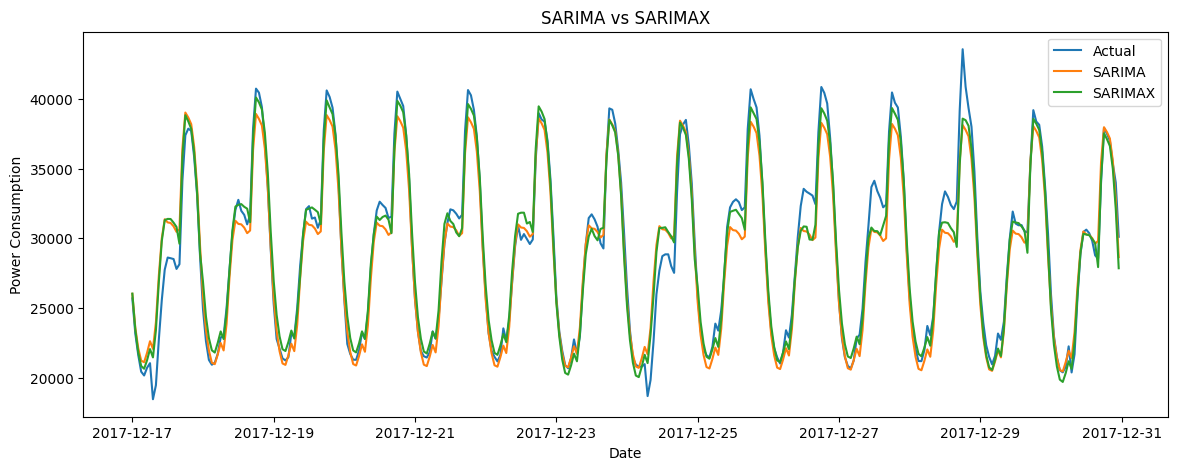

In [46]:
plot_start = y_test.index.max() - pd.Timedelta(days=5)

plt.figure(figsize=(14, 5))

plt.plot(y_test.loc[plot_start:].index, y_test.loc[plot_start:], label="Actual")
plt.plot(sarima_pred.loc[plot_start:].index, sarima_pred.loc[plot_start:], label="SARIMA")
plt.plot(sarimax_pred.loc[plot_start:].index, sarimax_pred.loc[plot_start:], label="SARIMAX")

plt.title("SARIMA vs SARIMAX - Last 5 Days")
plt.xlabel("Date")
plt.ylabel("Power Consumption")
plt.legend()

plt.show()

In [47]:
exog_weights = sarimax_result.params[sarimax_result.params.index.isin(all_exog)]

exog_weights

,0
Temperature,669.950675
Humidity,298.588486
Wind Speed,66.971371
general diffuse flows,-369.211063
diffuse flows,-954.672538
hour_sin,-5418.883383
hour_cos,-1438.887666
dayofweek,-249.130493
month,-2394.601202
is_weekend,-317.719111
